1. Carga de librerias

In [123]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

2. Carga del dataset

In [124]:
#cargamos el dataset
df = pd.read_csv(r"C:\Users\tifaw\OneDrive\Desktop\BOOTCAMP_DATASCIENCE\REPOSITORIO_GIT\Proyectos\ML_project_fatima\src\data\hotel_bookings.csv")

#Fuente: kaggle(https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand/data)

In [125]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


3. Exploración inicial de mi dataset

In [126]:
#Ver el Numero de filas y columnas.
df.shape

# dataset con 119,390 registros y 32 variables

(119390, 32)

In [127]:
df.info() 
# Número de filas: 119.390
# Número de columnas: 32
# columnas tipo object: 16 cols 
# Se observan valores nulos en algunas columnas.
# target: is_canceled   no presenta nulos y es de tipo int.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [128]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


C:\Users\tifaw\AppData\Local\Temp\ipykernel_35268\919073807.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='is_canceled', data=df, palette='magma')


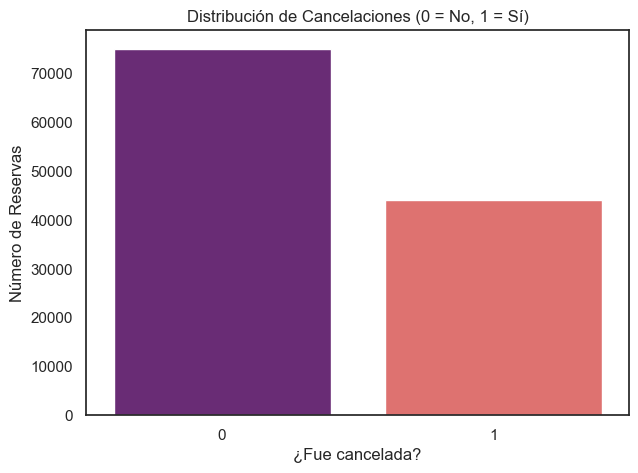

In [129]:
# 2. Gráfico de la Variable Objetivo o target (is_canceled)
plt.figure(figsize=(7, 5))
sns.countplot(x='is_canceled', data=df, palette='magma')
plt.title('Distribución de Cancelaciones (0 = No, 1 = Sí)')
plt.xlabel('¿Fue cancelada?')
plt.ylabel('Número de Reservas')
plt.show()

In [130]:
# Visualización de nulos por columna
df.isnull().sum()


hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

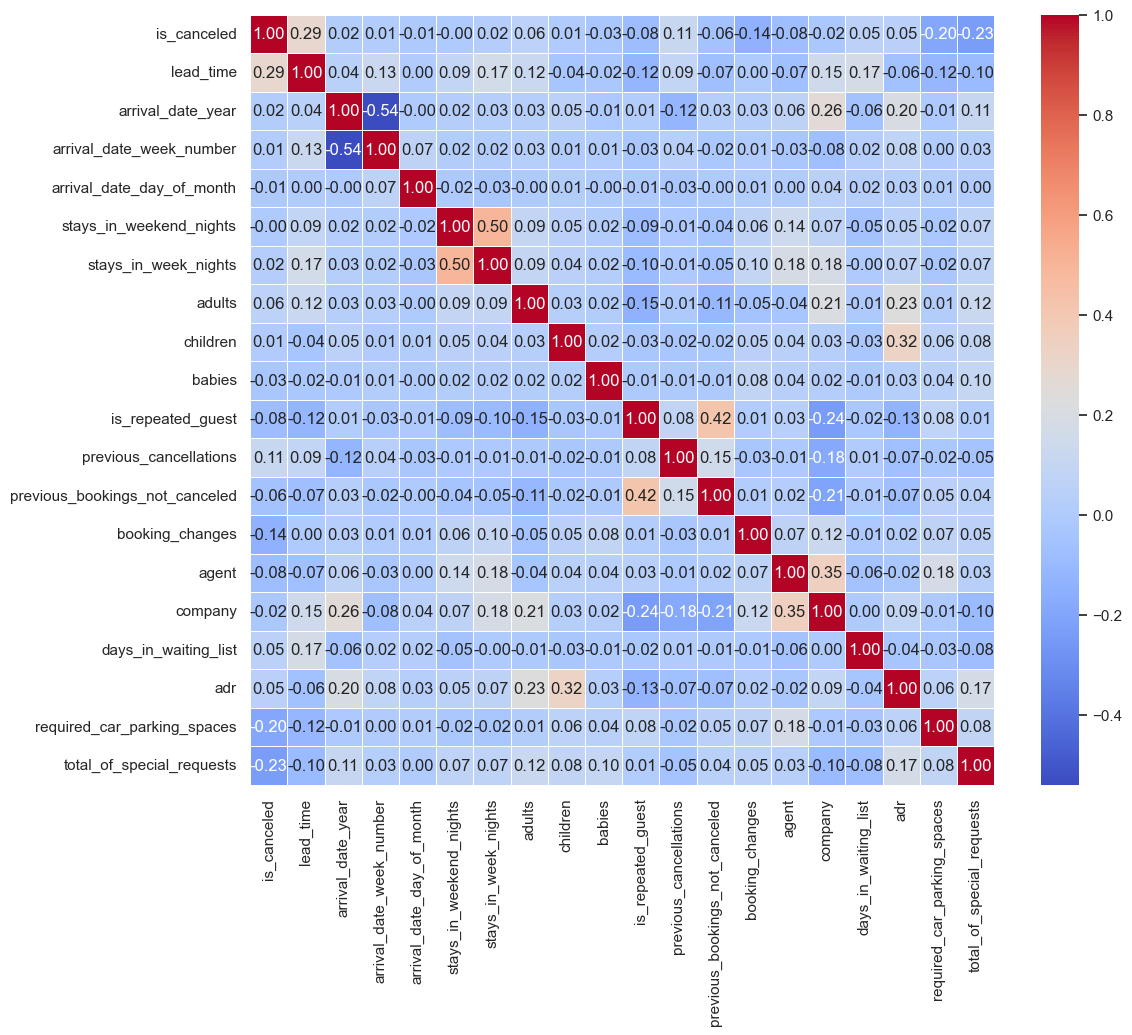

In [131]:
# Mapa de correlaciones con las variables que son numéricas

plt.figure(figsize=(12,10))  # aumenta el tamaño
sns.heatmap(
    df.select_dtypes(include='number').corr(),
    annot = True,
    cmap = 'coolwarm',
    fmt=".2f",        # solo 2 decimales
    linewidths=0.5    # separa las celdas)
)
plt.show()

# podemos ver que la variable que más correlación tiene con mi target es feature'leaad_time'(Días transcurridos entre la fecha de reserva y la fecha de llegada).

4. Limpieza de Datos (Data Cleaning)

In [132]:
# Función check missings en mi dataset
def check_missings(data):
    """
    Calcula nulos totales y porcentaje de cada columna que presente missings.
    Siguiendo el punto 11 de la guía de ML.
    """
     # 1. Calculamos nulos totales por columna
    # data.isnull() → devuelve True/False (True si es nulo)
    # .sum() → cuenta los True (porque True = 1)
    # 1. Calculamos nulos totales
    missings = data.isnull().sum()
    
    
    # 2. Filtramos solo las que tienen nulos > 0
     # missings > 0 → condición
    # nos quedamos solo con esas columnas
    missings = missings[missings > 0]
    
    # Si no hay columnas con nulos
    if missings.empty:
        
        return "No se encontraron valores nulos."
    
    # 3. Creamos un DataFrame para visualizar los resultados
    reporte_nulos = pd.DataFrame({
         # Número total de nulos por columna
        'Nulos': missings,
        # Porcentaje de nulos:
        # missings / len(data) → divide por número de filas
        # * 100 → lo convierte en %
        # .round(2) → redondea a 2 decimales
        'Porcentaje (%)': (missings / len(data) * 100).round(2)
        
    # Ordenamos de mayor a menor número de nulos    
    }).sort_values(by='Nulos', ascending=False)
    
    return reporte_nulos

# Uso de la función
check_missings(df)

,Nulos,Porcentaje (%)
company,112593,94.31
agent,16340,13.69
country,488,0.41
children,4,0.00


In [133]:
# 1. Antes de realizar cualquier cambio, hay que guardar una copia del data frame original.
# Crear una copia exacta e independiente
df_trabajo = df.copy()

# A partir de ahora todos los cambios se harán sobre el df_trabajo.
df_trabajo.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


Columna company: Tiene más del 90% de nulos. Eliminar la columna completa, ya que no aporta información estadística suficiente.<br>
voy a definir una funcion para reutilizar despues para el resto de columnas.


    
    

In [134]:
# Definimos funcion eliminar columnas

def borrar_columnas(data, lista_columnas):
    """
    Elimina columnas específicas de un DataFrame.

    Parámetros:
    -----------
    data : pandas.DataFrame
        DataFrame del que se desean eliminar columnas.

    lista_columnas : list
        Lista con los nombres de las columnas que se quieren borrar.

    Retorna:
    --------
    pandas.DataFrame
        DataFrame sin las columnas indicadas.
    """
    # errors='ignore' hace que si la columna no existe, simplemente la salte
    return data.drop(columns=lista_columnas, errors='ignore')

# --- Ejemplo de uso ---
columnas_a_eliminar = ['company']

# Aplicamos la función sobre nuestra COPIA
df_trabajo = borrar_columnas(df_trabajo, columnas_a_eliminar)

print(f"Columnas eliminadas. Ahora tienes {df_trabajo.shape[1]} columnas.") #shape[1] me devuelve el el segundo valor de la tupla(filas, columnas)

Columnas eliminadas. Ahora tienes 31 columnas.


Columna agent: Los nulos probablemente indican que la reserva no se hizo a través de una agencia. voy a sustituir los nulos por un valor 0.

In [135]:
# ver que valores únicos hay en esta columna
print(df_trabajo['agent'].unique())

# Sustituimos los valores nulos por 0
df_trabajo['agent'] = df_trabajo['agent'].fillna(0)

# Verificamos que ya no existan nulos en esa columna
print(f"Nulos en 'agent' después del cambio: {df_trabajo['agent'].isnull().sum()}")
print(df_trabajo['agent'].dtype)


[ nan 304. 240. 303.  15. 241.   8. 250. 115.   5. 175. 134. 156. 243.
 242.   3. 105.  40. 147. 306. 184.  96.   2. 127.  95. 146.   9. 177.
   6. 143. 244. 149. 167. 300. 171. 305.  67. 196. 152. 142. 261. 104.
  36.  26.  29. 258. 110.  71. 181.  88. 251. 275.  69. 248. 208. 256.
 314. 126. 281. 273. 253. 185. 330. 334. 328. 326. 321. 324. 313.  38.
 155.  68. 335. 308. 332.  94. 348. 310. 339. 375.  66. 327. 387. 298.
  91. 245. 385. 257. 393. 168. 405. 249. 315.  75. 128. 307.  11. 436.
   1. 201. 183. 223. 368. 336. 291. 464. 411. 481.  10. 154. 468. 410.
 390. 440. 495. 492. 493. 434.  57. 531. 420. 483. 526. 472. 429.  16.
 446.  34.  78. 139. 252. 270.  47. 114. 301. 193. 182. 135. 350. 195.
 352. 355. 159. 363. 384. 360. 331. 367.  64. 406. 163. 414. 333. 427.
 431. 430. 426. 438. 433. 418. 441. 282. 432.  72. 450. 180. 454. 455.
  59. 451. 254. 358. 469. 165. 467. 510. 337. 476. 502. 527. 479. 508.
 535. 302. 497. 187.  13.   7.  27.  14.  22.  17.  28.  42.  20.  19.
  45. 

Columna country, como tiene pocos nulos, voy a sustituirlo por la moda.<br>
Columna children como son pocos valores, vamos asumir que no tienen hijos, sustituimos null por 0.

In [136]:
#1. Country: El país más repetido (moda)
df_trabajo['country'] = df_trabajo['country'].fillna(df_trabajo['country'].mode()[0])

#2. Children: Asumimos 0 hijos
df_trabajo['children'] = df_trabajo['children'].fillna(0)

#Comprobación final de nulos.
print('Total de nulos en el dataset:', df_trabajo.isnull().sum().sum())


Total de nulos en el dataset: 0


In [137]:
df_trabajo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 31 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119390 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

is_canceled
0    62.958372
1    37.041628
Name: proportion, dtype: float64


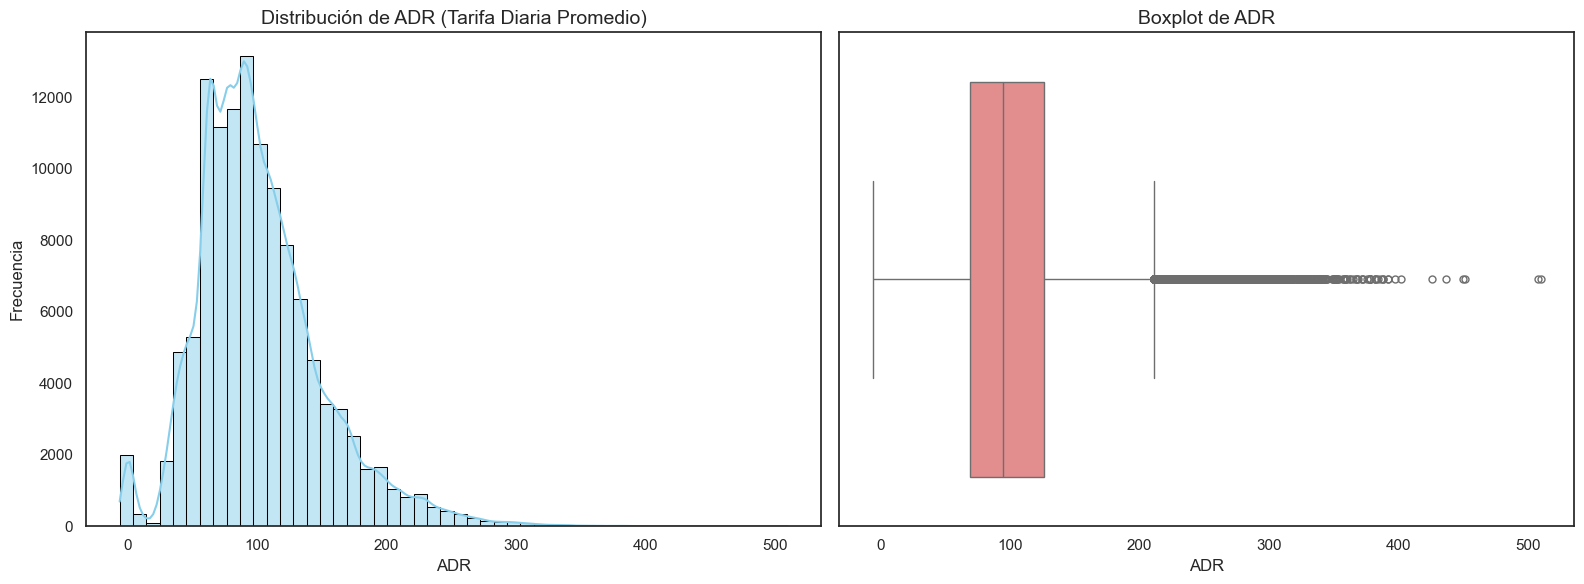

In [138]:
import matplotlib.pyplot as plt
import seaborn as sns
# Ver la proporción real de cancelaciones
print(df_trabajo['is_canceled'].value_counts(normalize=True) * 100)

# 1. Configuración del estilo
sns.set_theme(style="white") # Estilo limpio sin cuadrícula de fondo para esta versión

# 2. Filtrado opcional para mejorar la visibilidad (quitando el outlier extremo de 5400)
# Esto permite que el histograma y el boxplot se centren en el grueso de los datos
df_plot = df[df['adr'] < 1000]

# 3. Crear la figura y los ejes
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- GRÁFICA 1: HISTOGRAMA ---
sns.histplot(df_plot['adr'], bins=50, kde=True, color='skyblue', ax=axes[0], edgecolor='black')
axes[0].set_title('Distribución de ADR (Tarifa Diaria Promedio)', fontsize=14)
axes[0].set_xlabel('ADR')
axes[0].set_ylabel('Frecuencia')

# --- GRÁFICA 2: BOXPLOT ---
sns.boxplot(x=df_plot['adr'], color='lightcoral', ax=axes[1], fliersize=5)
axes[1].set_title('Boxplot de ADR', fontsize=14)
axes[1].set_xlabel('ADR')

# 4. Ajustar el diseño para que no se solapen
plt.tight_layout()

# 5. Mostrar
plt.show()

Conclusion: en la gráfica anterior, podemos deterctar varias cosas:<br>
#1. El valor mínimo está en negativo  (-6.38) esto no tiene sentido. 
#2. El histograma esta sestagado, el histograma tiene una cola larga hacía la derecha, lo que indica presencia de outliers.<br>
#3. La mayoria de las reservas son económicas pero hays reservas son económicas, pero hay muy pocos lientes que pagan muchísimo.

In [139]:
#1. Analizamos la distribución de feature 'adr'(Tarifa Diaria promedio)
print(df_trabajo['adr'].max())
print(df_trabajo['adr'].min())

# CUIDADO! el precio minímo es de -6.38. Este es claramente un error de datos o un ajuste contable que no nos sirve para predecir cancelaciones de clientes reales.
# Tratamiento:Eliminar la fila

#2. Ver cuántas reservas tienen ADR <= 0 y si cancelaron
print(df_trabajo[df_trabajo['adr'] <= 0]['is_canceled'].value_counts())

# Tenemos 1960 reservas que siendo el precio 0 o incluso menor:
    ##La gran mayoría (1,747) NO canceló: Esto da  la idea de que son "cortesías", habitaciones de empleados, o programas de puntos, (Si te regalan una habitación, es muy probable que vayas).
    ##La minoría (213) SÍ canceló: Son casos extraños donde incluso siendo "gratis" (o error de sistema), la reserva no se concretó.
# Como conclusión: Como estas reservas no siguen la lógica comercial estándar (donde hay un intercambio de dinero y un riesgo de pérdida financiera si se cancela), lo más sano para que mi modelo ML sea robusto es eliminarlas.


# Filtramos el dataframe para quedarnos solo con transacciones comerciales reales
df_trabajo = df_trabajo[df_trabajo['adr'] > 0]


# Verificamos que el valor mínimo ahora sea mayor a 0
print(f"Nuevo valor mínimo de ADR: {df_trabajo['adr'].min()}")
print(f"Registros restantes: {df_trabajo.shape[0]}")

#3.Tratamiento de outliers valor max.
#Como vimos en las estadísticas, la columna adr, tiene un valor máximo de 5400, mientras que la media es de apenas 101.
# Ese valor de 5400 es claramente un error o un ruido que puede confundir al modelo de Machine Learning.
# por lo que voy a proceder a elimar este outlier.
df_trabajo = df_trabajo[df_trabajo['adr']< 5000]
print(f"Nuevo valor máximo de ADR: {df_trabajo['adr'].max()}")
print(f"Registros restantes: {df_trabajo.shape[0]}")

5400.0
-6.38
is_canceled
0    1747
1     213
Name: count, dtype: int64
Nuevo valor mínimo de ADR: 0.26
Registros restantes: 117430
Nuevo valor máximo de ADR: 510.0
Registros restantes: 117429


Análisis de Dúplicados<br>


En este dataset de hoteles, es muy común que esto ocurra porque no hay una columna de "ID de Reserva" única.<br>
Para un modelo de Machine Learning, tener tantas filas idénticas puede causar "overfitting" (que el modelo memorice casos repetidos) y por tanto no genralizará bien<br>
y sesgar las estadísticas del análisis exploratorio. Al eliminarlos, nos quedamos con registros únicos que representan comportamientos distintos

Usar el método .duplicated(). Por defecto, este método marca como True todas las filas que son exactamente iguales a una fila anterior(considerando todas las columnas)<br>

In [140]:
# 1. Cuenta cuántas filas están repetidas en todo el dataset
total_duplicados = df_trabajo.duplicated().sum() #Cuenta solo las filas duplicadas EXCLUYENDO la primera aparición.
#(si una fila aparece 2 veces  cuenta 1; si aprece 3 veces cuenta 2; y si aparece 4 veces cuenta 3)
print(f"Total de registros idénticos: {total_duplicados}")


# 2. Extraemos todas las filas que tienen un duplicado
df_duplicados = df_trabajo[df_trabajo.duplicated(keep=False)] #keep=False nos muestra todas las copias del registro, no solo la repetida.
print(df_duplicados)
# # Eliminamos y guardamos los cambios en el mismo DataFrame
df_trabajo.drop_duplicates(inplace=True)

# Verificamos que ahora los duplicados sumen 0.
print(f"Duplicados tras la limpieza: {df_trabajo.duplicated().sum()}")

Total de registros idénticos: 31839
               hotel  is_canceled  lead_time  arrival_date_year  \
4       Resort Hotel            0         14               2015   
5       Resort Hotel            0         14               2015   
21      Resort Hotel            0         72               2015   
22      Resort Hotel            0         72               2015   
39      Resort Hotel            0         70               2015   
...              ...          ...        ...                ...   
119352    City Hotel            0         63               2017   
119353    City Hotel            0         63               2017   
119354    City Hotel            0         63               2017   
119372    City Hotel            0        175               2017   
119373    City Hotel            0        175               2017   

       arrival_date_month  arrival_date_week_number  \
4                    July                        27   
5                    July                        

In [141]:
df_trabajo.shape

(85590, 31)

5. Exploración (EDA)

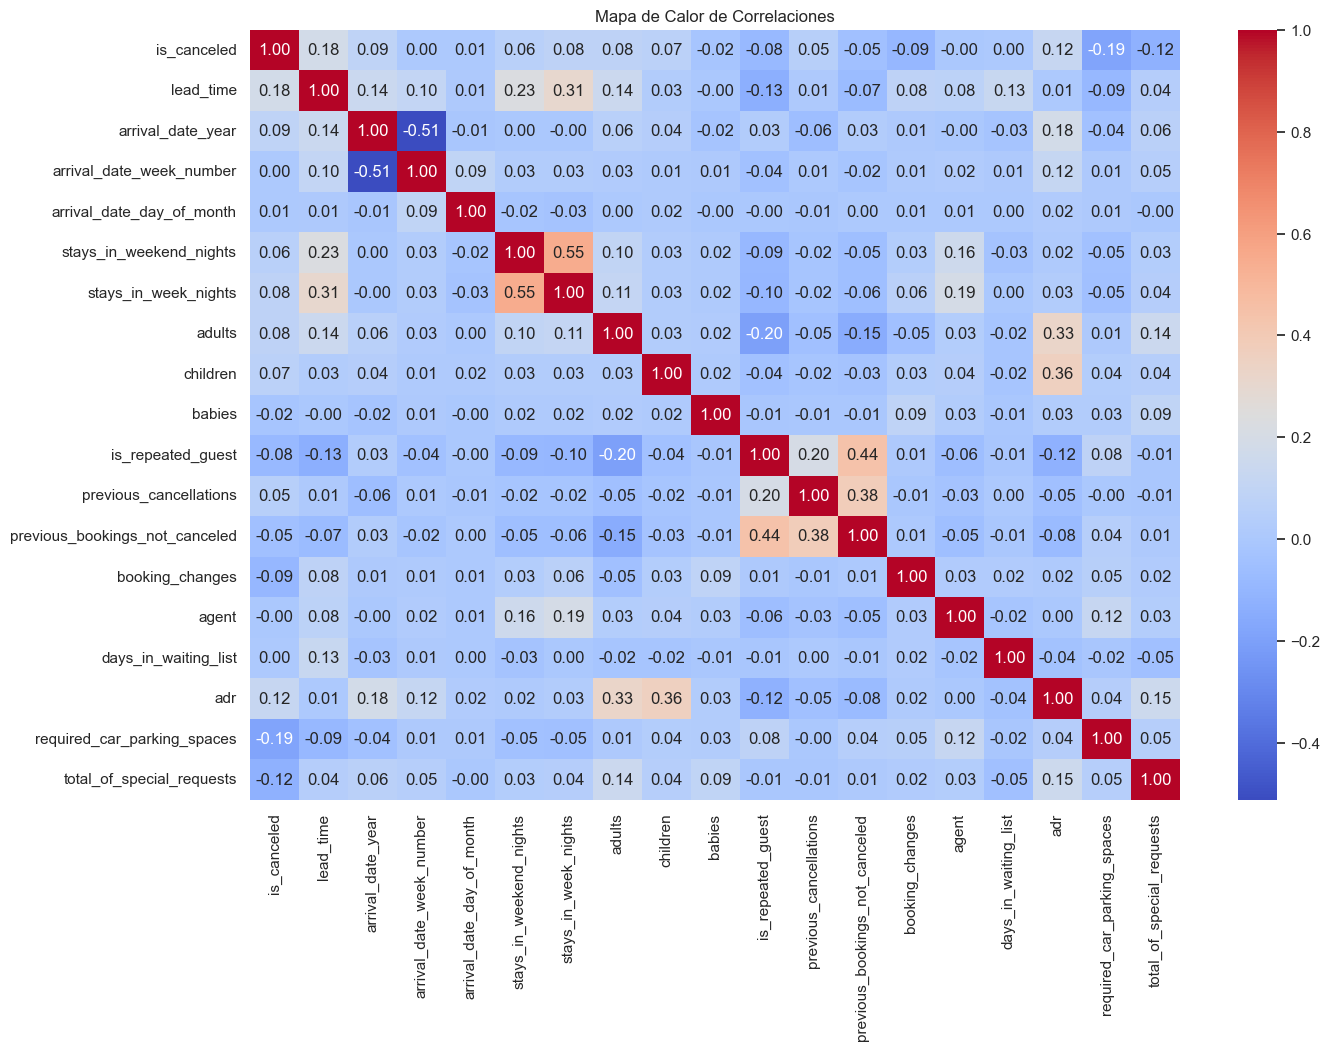

In [142]:
# Seleccionamos solo columnas numéricas para la correlación
plt.figure(figsize=(15, 10))
sns.heatmap(df_trabajo.corr(numeric_only=True), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Mapa de Calor de Correlaciones")
plt.show()

Las variables que mas correlación tiene  con mi target' is_canceled' son:<br>
1.lead_time(0.18):tiene correlacion positiva, a mayor antelación de la reserva, mayor es la probabilidad de que el cliente cancele.<br>
2.required_car_parking_spaces (-0.19): teine correlacion negativa, las personas que piden parking, casi nunca cancelan.<br>
3.total_of_special_requests (-0.12): cuantas más peticiones especiales ahce un cliente menos probalidad de que se cancele la reserva.<br>

In [143]:
df_trabajo.info()

<class 'pandas.core.frame.DataFrame'>
Index: 85590 entries, 2 to 119389
Data columns (total 31 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           85590 non-null  object 
 1   is_canceled                     85590 non-null  int64  
 2   lead_time                       85590 non-null  int64  
 3   arrival_date_year               85590 non-null  int64  
 4   arrival_date_month              85590 non-null  object 
 5   arrival_date_week_number        85590 non-null  int64  
 6   arrival_date_day_of_month       85590 non-null  int64  
 7   stays_in_weekend_nights         85590 non-null  int64  
 8   stays_in_week_nights            85590 non-null  int64  
 9   adults                          85590 non-null  int64  
 10  children                        85590 non-null  float64
 11  babies                          85590 non-null  int64  
 12  meal                            8559

Análisis de la variable objetivo tras cambios anteriores

is_canceled
0    72.148615
1    27.851385
Name: proportion, dtype: float64


C:\Users\tifaw\AppData\Local\Temp\ipykernel_35268\1859286399.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_trabajo, x='is_canceled', palette='Set2')


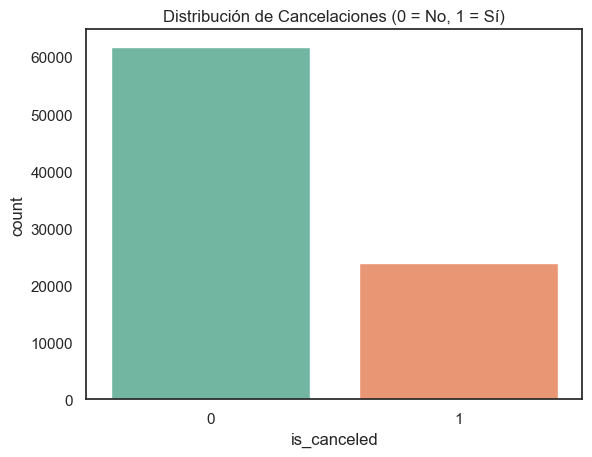

In [144]:
# 1. Ver la proporción real de cancelaciones
print(df_trabajo['is_canceled'].value_counts(normalize=True) * 100)

sns.countplot(data=df_trabajo, x='is_canceled', palette='Set2')
plt.title('Distribución de Cancelaciones (0 = No, 1 = Sí)')
plt.show()

# La grafica muestra que el dataset sigue desbalanceado, tras eliminar duplicados, la mayoria de la gente no cancela las reservas. el porcentaje de cancelacione redondeando al alza es del 28%.

Análisis de las variables numéricas

#.1.lead_time, adr,required_car_parking_spaces,total_of_special_requests vs is_canceled

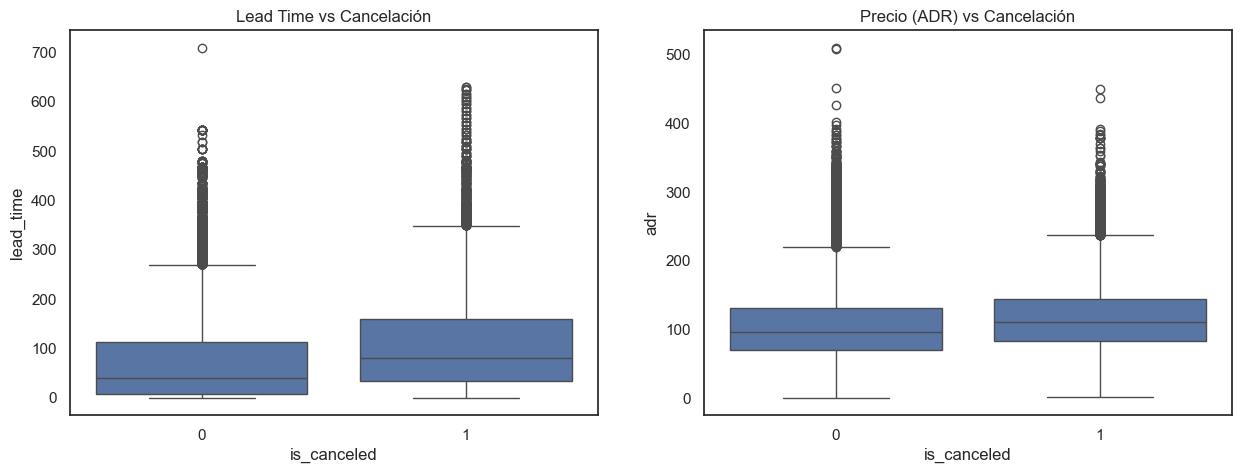

In [145]:
# Lead Time(días entre reserva y llegada) vs Cancelación y adr(precio por día)
#1. Comparación mediante Boxplots para detectar patrones y outliers
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(data=df_trabajo, x='is_canceled', y='lead_time', ax=axes[0])
axes[0].set_title('Lead Time vs Cancelación')

#2. Comparación mediante Boxplots para detectar patrones y outliers
sns.boxplot(data=df_trabajo, x='is_canceled', y='adr', ax=axes[1])
axes[1].set_title('Precio (ADR) vs Cancelación')

plt.show()


1.Lead Time vs Cancelación: podemos ver que las reservas canceladas tiene mayor lead time, y las no canceladas tiene un lead time bajo, esto quiere decir que, cuando un cliente reserva con mayor antelación, hay más probabilidad que que cancele la resrva. outliers; hay muchos valores extremos, revervas hechas hasta 700 días de antelación. <br>
<br>
2.ADR (precio) vs Cancelación: el ADR(tarifa promedio al día) no muestra una diferencia clara entre reservas canceladas y no canceladas. Las medianas son similares, e incluso en algunos casos las reservas no canceladas presentan valores ligeramente superiores. Esto sugiere que el precio no es un factor determinante en la cancelación.

valores únicos Plazas de Parking [0 1 2 8 3]
required_car_parking_spaces
0    78380
1     7177
2       28
3        3
8        2
Name: count, dtype: int64
valores únicos Peticiones Especiales [0 1 3 2 4 5]
total_of_special_requests
0    42847
1    28537
2    11609
3     2257
4      304
5       36
Name: count, dtype: int64


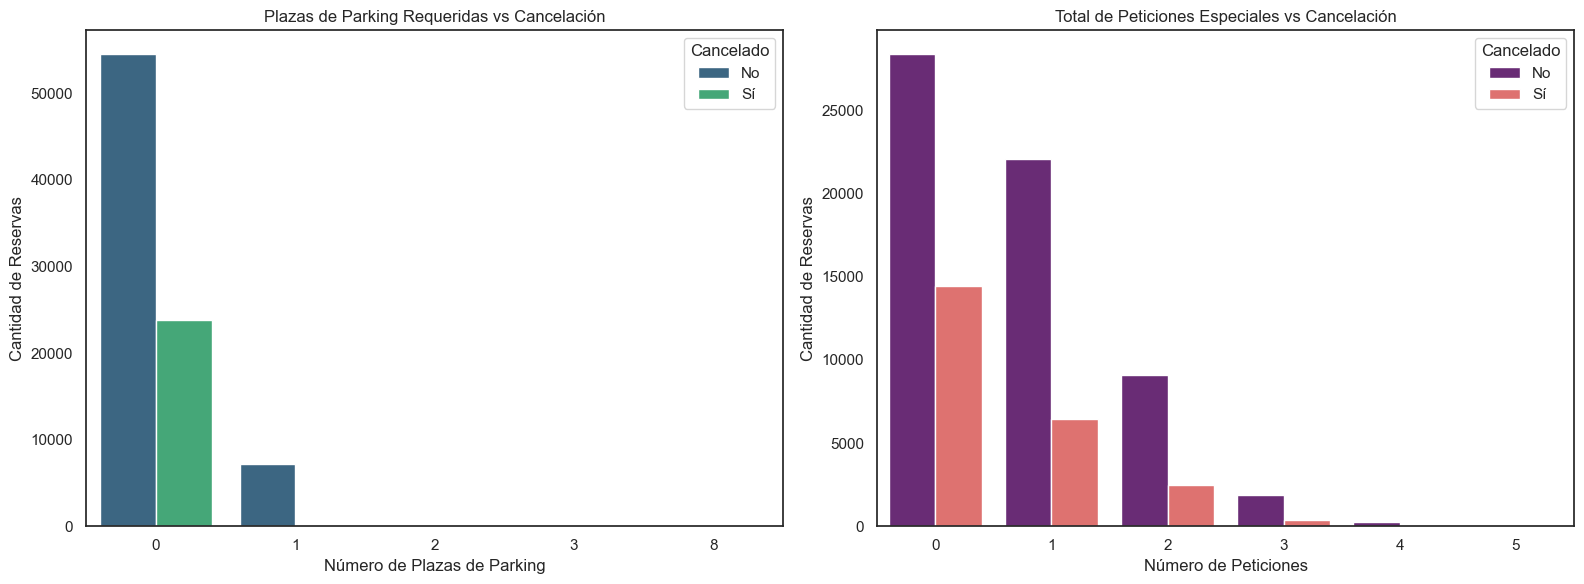

Tasa de cancelación por Peticiones Especiales:
total_of_special_requests
0    33.712979
1    22.658303
2    21.517788
3    17.456801
4    10.855263
5     5.555556
Name: is_canceled, dtype: float64


In [146]:
# required_car_parking_spaces,total_of_special_requests vs is_canceled

print("valores únicos Plazas de Parking", df_trabajo['required_car_parking_spaces'].unique())
print(df_trabajo['required_car_parking_spaces'].value_counts())
print('==========================')
print("valores únicos Peticiones Especiales", df_trabajo['total_of_special_requests'].unique())
print(df_trabajo['total_of_special_requests'].value_counts())
# 3. Configuración del lienzo (Subplots)
# Creamos una figura con 1 fila y 2 columnas
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Gráfico 1: Plazas de Parking ---
sns.countplot(
    data=df_trabajo, 
    x='required_car_parking_spaces', 
    hue='is_canceled', 
    ax=axes[0], 
    palette='viridis'
)
axes[0].set_title('Plazas de Parking Requeridas vs Cancelación')
axes[0].set_xlabel('Número de Plazas de Parking')
axes[0].set_ylabel('Cantidad de Reservas')
axes[0].legend(title='Cancelado', labels=['No', 'Sí'])

# --- Gráfico 2: Peticiones Especiales ---
sns.countplot(
    data=df_trabajo, 
    x='total_of_special_requests', 
    hue='is_canceled', 
    ax=axes[1], 
    palette='magma'
)
axes[1].set_title('Total de Peticiones Especiales vs Cancelación')
axes[1].set_xlabel('Número de Peticiones')
axes[1].set_ylabel('Cantidad de Reservas')
axes[1].legend(title='Cancelado', labels=['No', 'Sí'])

# Ajustar el espacio entre gráficas para que no se solapen
plt.tight_layout()

# Mostrar los gráficos
plt.show()

# 4. Cálculo de tasas de cancelación
print("Tasa de cancelación por Peticiones Especiales:")
print(df_trabajo.groupby('total_of_special_requests')['is_canceled'].mean() * 100)


In [147]:
# 1. required_car_parking_spaces: Los datos muestran que nadie que haya solicitado al menos una plaza de parking ha cancelado su reserva.
# 2. En cuanto a peticiones especiales del cliente, viendo los porcentajes de cancelación por peticion especial, puedo concluir que cuantas mas peticiones hace el cliente menos probabilidad de que cancele la reserva.


Análisis de las variables categóricas

In [148]:
# Comprobamos qué columnas son categóricas para analizar.
df_trabajo.select_dtypes(include='object').info()

<class 'pandas.core.frame.DataFrame'>
Index: 85590 entries, 2 to 119389
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   hotel                    85590 non-null  object
 1   arrival_date_month       85590 non-null  object
 2   meal                     85590 non-null  object
 3   country                  85590 non-null  object
 4   market_segment           85590 non-null  object
 5   distribution_channel     85590 non-null  object
 6   reserved_room_type       85590 non-null  object
 7   assigned_room_type       85590 non-null  object
 8   deposit_type             85590 non-null  object
 9   customer_type            85590 non-null  object
 10  reservation_status       85590 non-null  object
 11  reservation_status_date  85590 non-null  object
dtypes: object(12)
memory usage: 8.5+ MB


In [149]:
# CUIDADO! LAS VARIABLES QUE NO DEBO INCLUIR EN EL MODELO por en ellas viene información de lo que queremos predecir.

#1. reservation_status:Esta variable nos dice si la reserva fue "Canceled", "Check-out" o "No-Show". Si la incluyo, el modelo tendrá un 100% de acierto porque le estoy dando la respuesta final.
#2. reservation_status_date:Es la fecha en la que cambió el estado. Al igual que la anterior, solo se conoce cuando la cancelación ya ocurrió.

# imprimimos el contenido de las columnas a eliminar.
print("reservation_status contiene la siguiente informacion que no se debe incluir en el modelo",df_trabajo['reservation_status'].value_counts())
print('===========================================')
print("reservation_status_date contiene la siguiente informacion que no se debe incluir en el modelo",df_trabajo['reservation_status_date'].value_counts())

# Elimino las columnas llamando a la funcion que hemos definido arriba.
columnas_a_eliminar =['reservation_status','reservation_status_date']
df_trabajo = borrar_columnas(df_trabajo, columnas_a_eliminar)

#comprobamos que se han eliminado
print(df_trabajo.columns)


reservation_status contiene la siguiente informacion que no se debe incluir en el modelo reservation_status
Check-Out    61752
Canceled     22849
No-Show        989
Name: count, dtype: int64
reservation_status_date contiene la siguiente informacion que no se debe incluir en el modelo reservation_status_date
2016-02-14    207
2017-05-25    198
2016-03-28    193
2015-10-21    193
2016-10-06    192
             ... 
2015-03-18      1
2015-01-20      1
2015-02-17      1
2015-03-10      1
2015-03-23      1
Name: count, Length: 924, dtype: int64
Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room

In [150]:
print('hotel:',df_trabajo['hotel'].unique())
print('meses:',df_trabajo['arrival_date_month'].unique())
print('menu:',df_trabajo['meal'].unique())
print('segmento de mercado por el que llegó la reserva:', df_trabajo['market_segment'].unique())
print('medio por el que llego la reserva:',df_trabajo['distribution_channel'].unique())
print('tipo de depósito:',df_trabajo['deposit_type'].unique())
print('tipo de cliente:',df_trabajo['customer_type'].unique())

hotel: ['Resort Hotel' 'City Hotel']
meses: ['July' 'August' 'September' 'October' 'November' 'December' 'January'
 'February' 'March' 'April' 'May' 'June']
menu: ['BB' 'FB' 'HB' 'SC' 'Undefined']
segmento de mercado por el que llegó la reserva: ['Direct' 'Corporate' 'Online TA' 'Offline TA/TO' 'Groups' 'Complementary'
 'Undefined' 'Aviation']
medio por el que llego la reserva: ['Direct' 'Corporate' 'TA/TO' 'Undefined' 'GDS']
tipo de depósito: ['No Deposit' 'Refundable' 'Non Refund']
tipo de cliente: ['Transient' 'Contract' 'Transient-Party' 'Group']


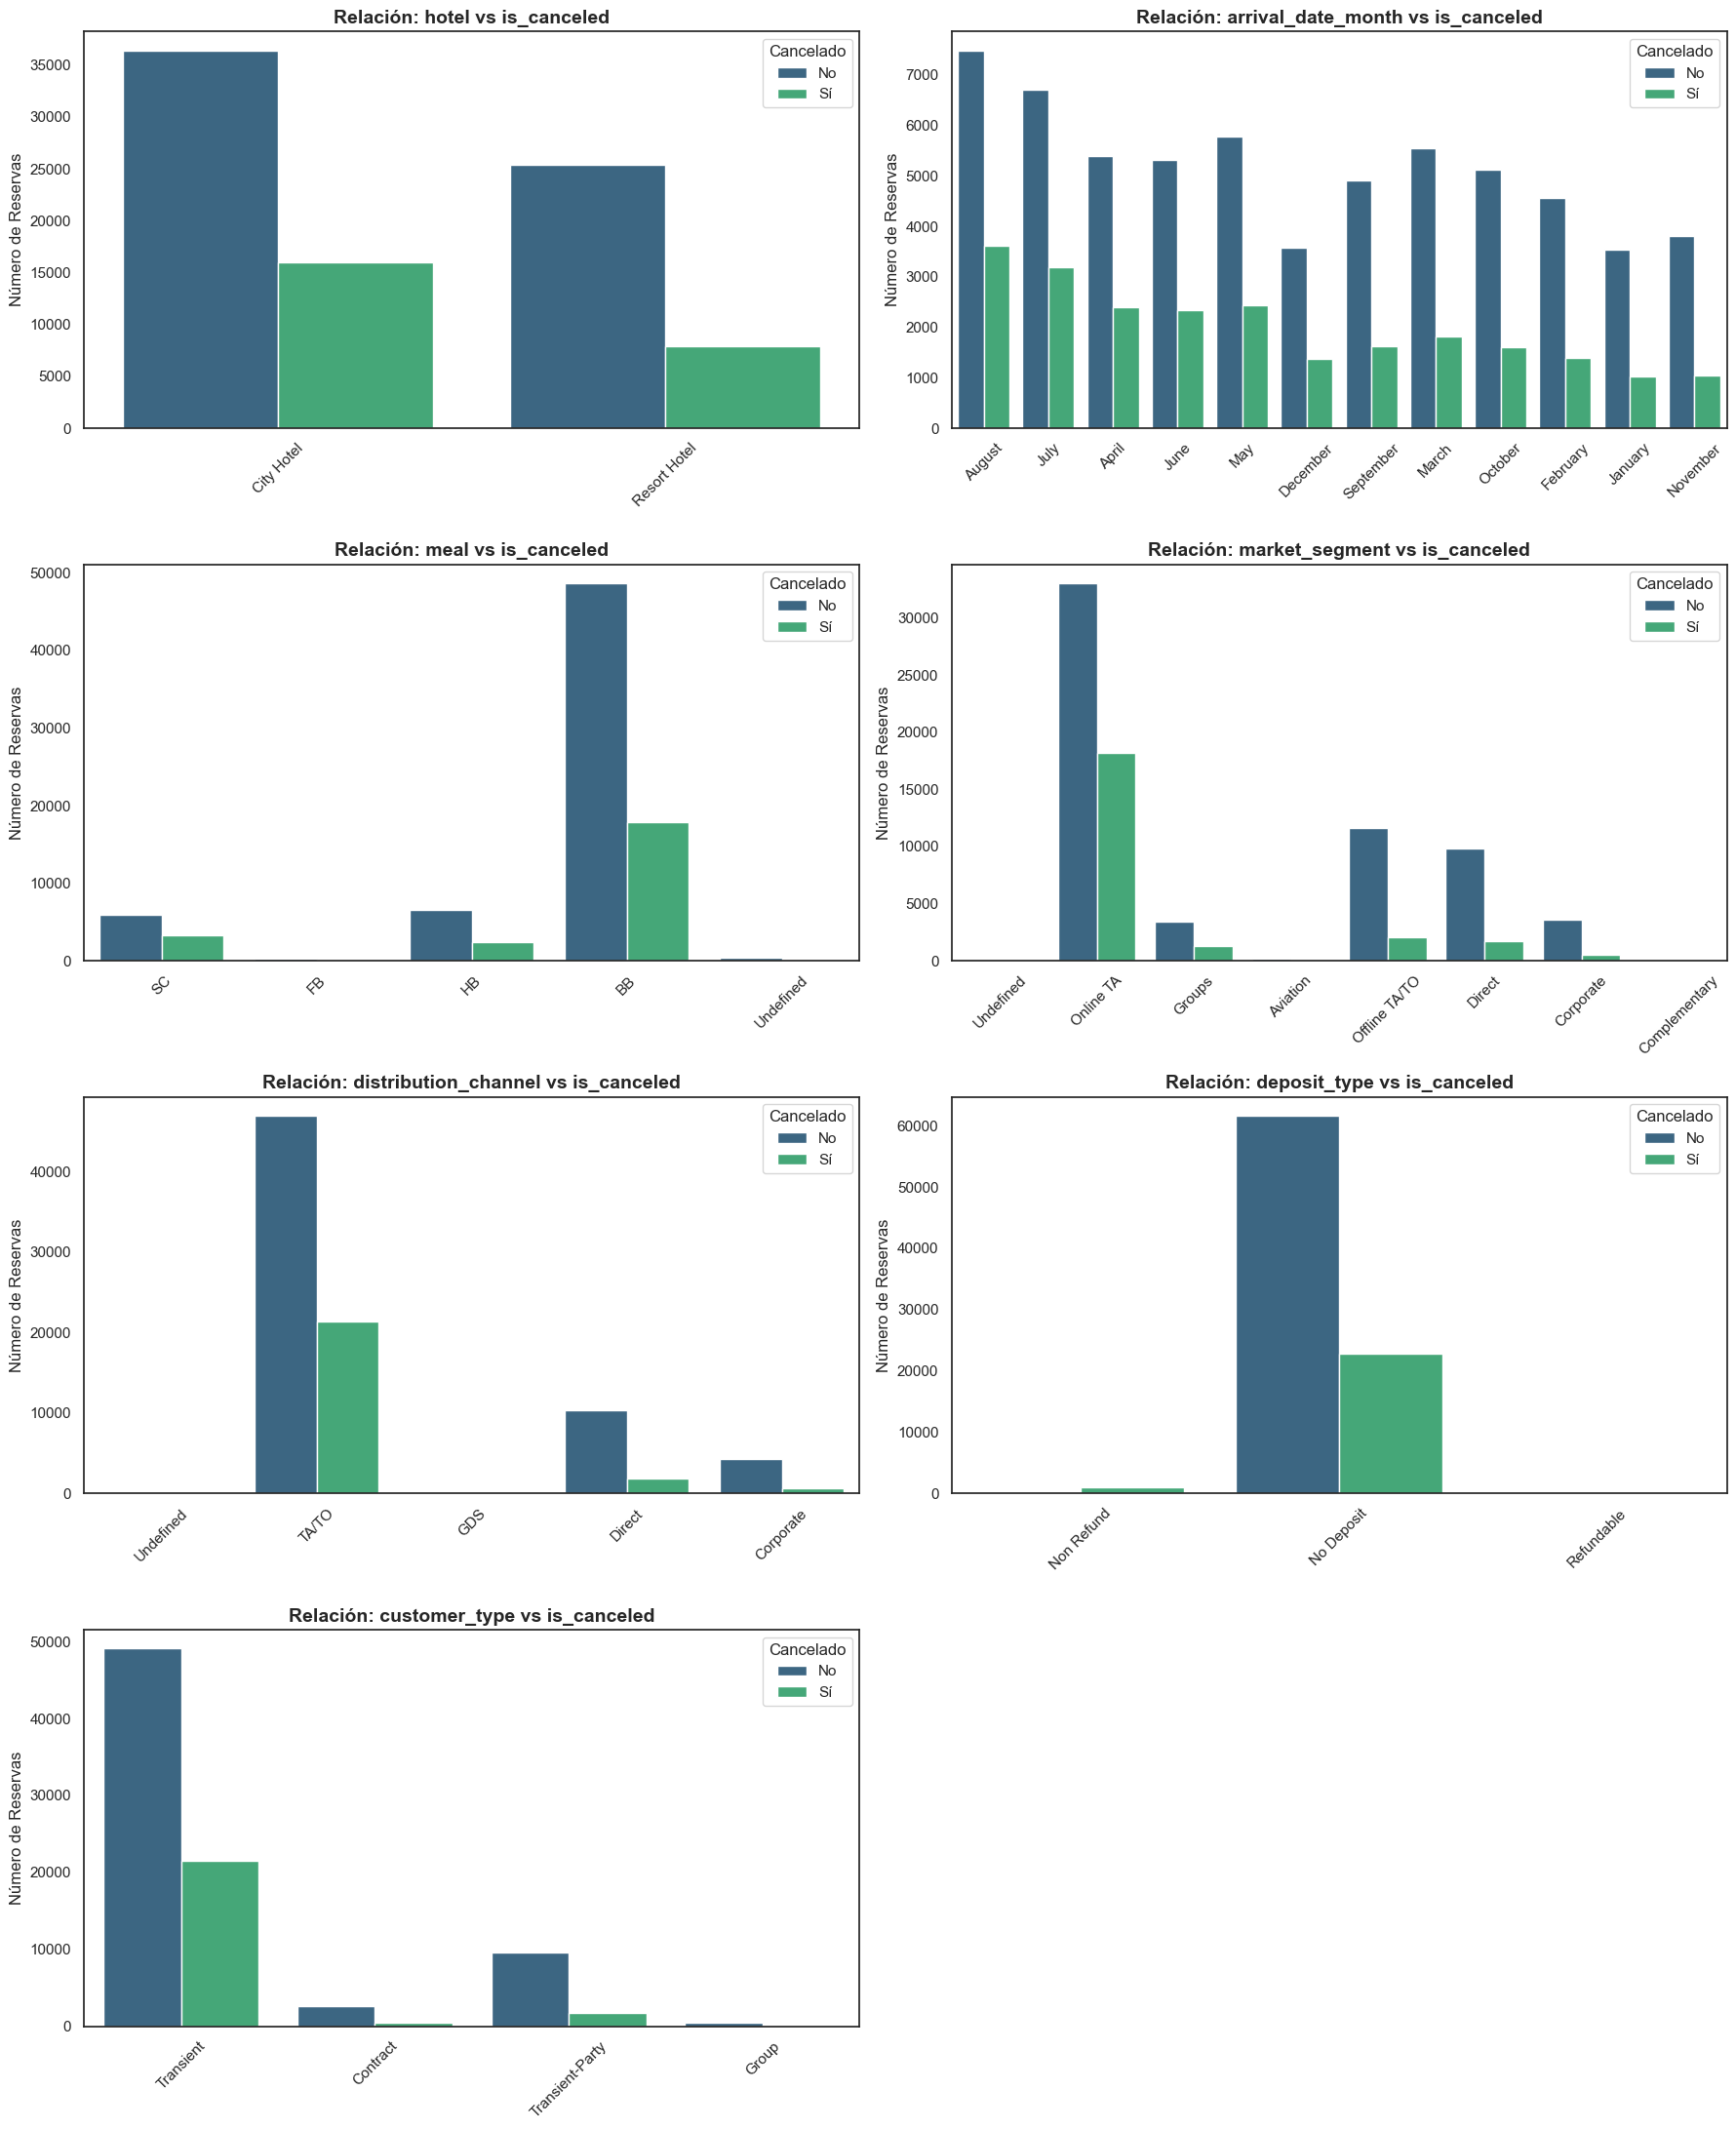


TASAS DE CANCELACIÓN POR CATEGORÍA (%)

--- hotel ---
hotel
City Hotel      30.45%
Resort Hotel    23.77%
Name: is_canceled, dtype: object

--- arrival_date_month ---
arrival_date_month
August       32.55%
July         32.15%
April        30.75%
June         30.63%
May          29.57%
December     27.65%
September    24.76%
March        24.68%
October      23.94%
February     23.45%
January      22.45%
November     21.49%
Name: is_canceled, dtype: object

--- meal ---
meal
SC           35.81%
FB           28.49%
HB           27.24%
BB           26.89%
Undefined    17.39%
Name: is_canceled, dtype: object

--- market_segment ---
market_segment
Undefined        100.00%
Online TA         35.56%
Groups            27.87%
Aviation          19.82%
Offline TA/TO     14.90%
Direct            14.79%
Corporate         12.23%
Complementary      8.06%
Name: is_canceled, dtype: object

--- distribution_channel ---
distribution_channel
Undefined    80.00%
TA/TO        31.24%
GDS          20.34%
Direc

In [151]:
# 2. Definir variables categóricas
cat_vars = ['hotel', 'arrival_date_month', 'meal', 'market_segment', 
            'distribution_channel', 'deposit_type', 'customer_type']

# 3. Crear la cuadrícula de gráficos
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(18, 22))
axes = axes.flatten()

# 4. Generar gráficos comparativos
for i, var in enumerate(cat_vars):
    # Ordenar por tasa de cancelación de mayor a menor
    order = df_trabajo.groupby(var)['is_canceled'].mean().sort_values(ascending=False).index
    
    sns.countplot(
        data=df_trabajo, 
        x=var, 
        hue='is_canceled', 
        ax=axes[i], 
        order=order, 
        palette='viridis'
    )
    
    axes[i].set_title(f'Relación: {var} vs is_canceled', fontsize=14, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Número de Reservas')
    axes[i].legend(title='Cancelado', labels=['No', 'Sí'])

# Eliminar el eje sobrante
if len(cat_vars) < len(axes):
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

# 5. Resumen numérico de tasas (%)
print("\nTASAS DE CANCELACIÓN POR CATEGORÍA (%)")
for var in cat_vars:
    rate = (df_trabajo.groupby(var)['is_canceled'].mean() * 100).sort_values(ascending=False)
    print(f"\n--- {var} ---")
    print(rate.map('{:.2f}%'.format))
    
    


In [152]:
# Comprobación de cancelaciones en %  de deposit_type
resumen_deposito = df_trabajo.groupby('deposit_type')['is_canceled'].value_counts(normalize=True).unstack() * 100
resumen_deposito['Total_Reservas'] = df_trabajo.groupby('deposit_type').size()

print("Porcentaje de cancelación por tipo de depósito:")
print(resumen_deposito)

Porcentaje de cancelación por tipo de depósito:
is_canceled           0          1  Total_Reservas
deposit_type                                      
No Deposit    72.964972  27.035028           84446
Non Refund     5.303761  94.696239            1037
Refundable    75.700935  24.299065             107


In [153]:
# -----Conclusiones----
# 1. Los ciyt hotel es el que tiene una tasa de cancelación mayor,indicando que esta variable podría tener capacidad predictiva sobre el target.
# 2. Existe estacionalidad  en las cancelaciones, ya que en verano: agosto y julio es cuando más aumenta la tasa de cancelacióne.
# 3. Las reservas hechas por el cliente a través de agencia de viajes online (online TA) son las que más tasa de cancelación tienen.
# 4. Las reservas sin depósito son las más frecuentes y también las que presentan mayor número de cancelaciones.
# 5. Los clientes "Transient" (transeúntes o individuales) son los más propensos a cancelar en comparacion con los que vienen por contrato o en grupo.


In [154]:
# Variables valtantes por analizar
print('hotel:',df_trabajo['hotel'].unique())
print('reserved_room_type:', df_trabajo['reserved_room_type'].unique())
print('assigned_room_type:', df_trabajo['assigned_room_type'].unique())

hotel: ['Resort Hotel' 'City Hotel']
reserved_room_type: ['A' 'C' 'D' 'E' 'G' 'F' 'H' 'L' 'B']
assigned_room_type: ['C' 'A' 'D' 'E' 'G' 'F' 'I' 'B' 'H' 'L' 'K']


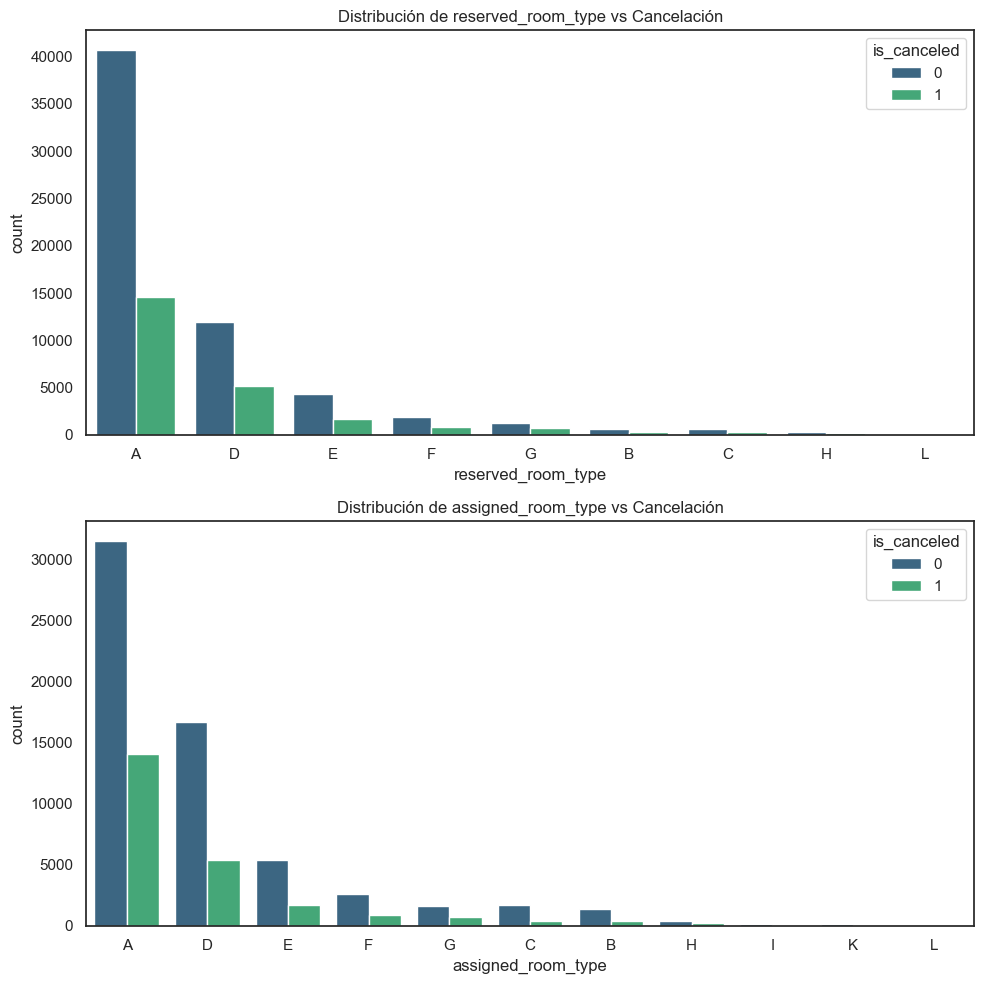

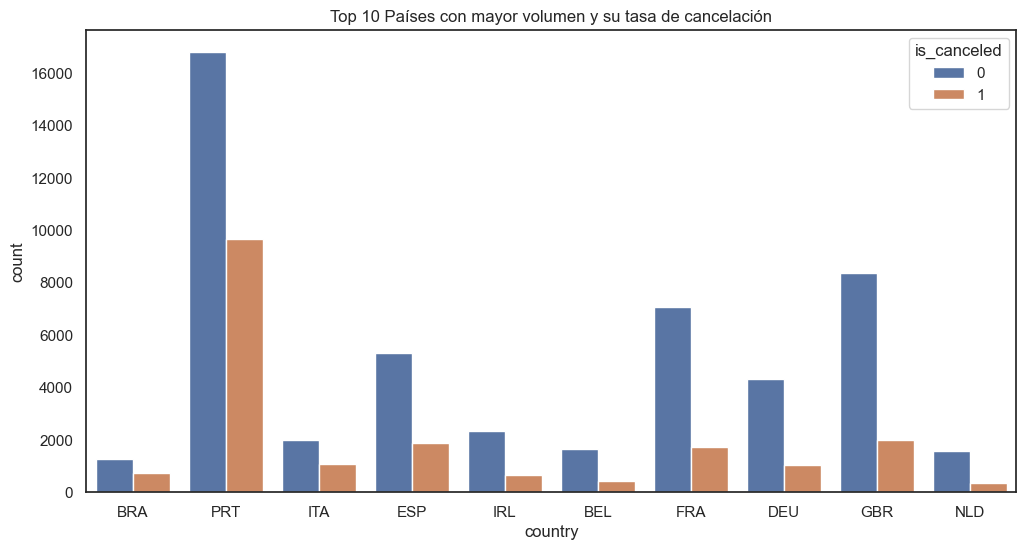

In [155]:
# Visualización Variables que faltaban por analizar: 
extra_vars = ['reserved_room_type', 'assigned_room_type']

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 10))

for i, var in enumerate(extra_vars):
    order = df_trabajo[var].value_counts().index
    sns.countplot(data=df_trabajo, x=var, hue='is_canceled', ax=axes[i], order=order, palette='viridis')
    axes[i].set_title(f'Distribución de {var} vs Cancelación')

plt.tight_layout()
plt.show()

# Análisis especial para 'country' (Top 10)
top_countries = df_trabajo['country'].value_counts().head(10).index
df_top_countries = df_trabajo[df_trabajo['country'].isin(top_countries)]

plt.figure(figsize=(12, 6))
sns.countplot(data=df_top_countries, x='country', hue='is_canceled', 
              order=df_top_countries.groupby('country')['is_canceled'].mean().sort_values(ascending=False).index)
plt.title('Top 10 Países con mayor volumen y su tasa de cancelación')
plt.show()

En el gráfico podemos ver que Portugal es el país que mas reservas realiza, pero también es el que tiene mayores tasas de cancelacion.

6. Feature engineering

In [156]:
# Trabajamos sobre una copia 
df_ml = df_trabajo.copy()
df_ml.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests'],
      dtype='object')

FEATURE ENGINEERING TRADUCCIÓN DE CATEGORÍAS: usaremos:<br>
    1. On hot enconding get dummies: para columnas con pocos valores únicos.<br>
    2. Label Encoding: para columnas con muchos valores únicos.<br>
    3.NOTA: se aplica Label Encoding para transformar las variables categóricas en valores numéricos, ya que el problema planteado es de clasificación y los modelos basados en árboles de decisión no se ven especialmente afectados por el orden artificial que este tipo de codificación puede introducir entre categorías.
   

In [157]:
# 1.COLUMNAS CATEGÓRICAS : METODO ONE-HOT ENCODING; GET DUMMIES.
# columnas hotel', 'meal', 'deposit_type', 'customer_type'
df_ml = pd.get_dummies(df_ml, columns=['hotel', 'meal', 'deposit_type', 'customer_type'])

# 2.COLUMNAS CATEGÓRICAS : METODO label encoder; 
# 1. Mapeo de Meses (Orden Cronológico)
# Creamos diccionario clave: valor.
meses_map = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4, 
    'May': 5, 'June': 6, 'July': 7, 'August': 8, 
    'September': 9, 'October': 10, 'November': 11, 'December': 12
}
# Asignamos el valor en el dataframe.
df_ml['arrival_date_month'] = df_ml['arrival_date_month'].map(meses_map) #map busca cada valor de la columna dentro del diccionario.

# 2. Mapeo de Segmentos de Mercado
# Asignamos números fijos para saber siempre qué significa cada uno
market_map = {
    'Direct': 1, 
    'Corporate': 2, 
    'Online TA': 3, 
    'Offline TA/TO': 4, 
    'Groups': 5, 
    'Aviation': 6, 
    'Complementary': 7, 
    'Undefined': 0
}
df_ml['market_segment'] = df_ml['market_segment'].map(market_map)

# 3. Mapeo de Canales de Distribución
dist_map = {
    'Direct': 1, 
    'Corporate': 2, 
    'TA/TO': 3, 
    'GDS': 4, 
    'Undefined': 0
}
df_ml['distribution_channel'] = df_ml['distribution_channel'].map(dist_map)

# 4. Verificación de nulos post-mapeo
# Si alguna palabra no estaba en el diccionario, aparecerá como NaN
print("Nulos generados por el mapeo:", df_ml[['arrival_date_month', 'market_segment', 'distribution_channel']].isnull().sum())

Nulos generados por el mapeo: arrival_date_month      0
market_segment          0
distribution_channel    0
dtype: int64


In [158]:
# Agrupamos columnas para reducir ruido en el modelo.

# 1. Total de personas: sumanos(Adultos, niños y bebés)
df_ml['total_guests'] = df_ml['adults'] + df_ml['children'] + df_ml['babies']

# 2. Estancia total: sumanos entre semana y fin de semana
df_ml['total_stays'] = df_ml['stays_in_weekend_nights'] + df_ml['stays_in_week_nights']

# 3. Cambio de habitacion: ¿Le dieron la que pidió? (Indica satisfacción),creamos una variable booleana(0 o 1)
df_ml ['room_changed'] = (df_ml['reserved_room_type'] != df_ml['assigned_room_type']).astype(int)
# En la variable 'previous_cancellations' voy a transformarla en una columna binaria de "Sí o No" (1 o 0),
print(df_ml['previous_cancellations'].value_counts()) # vemos que la mayoria no canceló.

# 4. Crear la nueva variable 'had_prev_cancellations' y eliminar previous_cancellations
# La lógica es: Si 'previous_cancellations' es mayor que 0, ponemos un 1 (Sí). 
# Si es 0, ponemos un 0 (No).
df_ml['had_prev_cancellations'] = df_ml['previous_cancellations'].apply(lambda x: 1 if x > 0 else 0)

# Comprobamos el cambio
print("Resumen de historial de cancelaciones:")
print(df_ml['had_prev_cancellations'].value_counts())

# 5. Eliminación de columnas originales.
#llamanos a la funcion de borrar_columna
columnas_a_eliminar =[
    'adults','children','babies',
    'stays_in_weekend_nights','stays_in_week_nights',
    'reserved_room_type','assigned_room_type',
    'previous_cancellations'
    ]
df_ml = borrar_columnas(df_ml, columnas_a_eliminar)


previous_cancellations
0     83988
1      1369
2        93
3        54
11       27
6        17
4        16
5        14
13        4
25        2
24        2
14        1
26        1
19        1
21        1
Name: count, dtype: int64
Resumen de historial de cancelaciones:
had_prev_cancellations
0    83988
1     1602
Name: count, dtype: int64


La columna 'country' como tiene demasiados valores únicos, vamos a coger sólo los más frecuentes y el resto lo clasificamos como "Other".<br>


In [159]:
# Miramos qué valores únicos hay.
print('tipo de cliente:',df_ml['country'].unique()) # muchos valores en la columna.

# PASO 1: ¿Quiénes son los 10 más frecuentes?
# Contamos cuántas veces aparece cada país y nos quedamos con los top 10.
top_10_country =df_ml['country'].value_counts().head(10).index # cuenta cuandas veces aparece cada valor y me devuelve los 10 priemros.

# PASO 2: Hacemos lo siguiente.
# Si el país de la reserva está en nuestro Top 10, lo dejamos igual.
# Si NO está, le ponemos la etiqueta 'Other'.
df_ml['country'] = df_ml['country'].apply(lambda x: x if x in top_10_country else 'Other') # ablicamos funcion landa x:dodne x representa cada pais.
# Comprobamos que se ha el cambio en la columna country.
print('tipo de cliente:',df_ml['country'].unique()) # muchos valores en la columna.

# PASO 3: Convertir a números, usando el método label Encoding.
# Ahora que solo tenemos 11 categorías (los 10 top + 'Other'), las numeramos del 1 al 10.
# 3. Creamos el diccionacion clave-valor
country_map = {
    'GBR': 1, #UK
    'PRT': 2, 
    'Other': 3, 
    'ESP': 4, 
    'IRL': 5,
    'FRA': 6,
    'DEU': 7,
    'BEL' : 8,
    'ITA': 9,
    'NLD': 10, #países bajos
    'BRA': 11
}
# Aplicamos los cambios.
df_ml['country'] = df_ml['country'].map(country_map)

# 4. Verificación de nulos post-mapeo
# Si alguna palabra no estaba en el diccionario, aparecerá como NaN
print("Nulos generados por el mapeo:", df_ml[['country']].isnull().sum())

tipo de cliente: ['GBR' 'PRT' 'USA' 'ESP' 'IRL' 'FRA' 'ROU' 'NOR' 'OMN' 'ARG' 'POL' 'DEU'
 'BEL' 'CHE' 'CN' 'GRC' 'ITA' 'NLD' 'DNK' 'RUS' 'SWE' 'AUS' 'EST' 'CZE'
 'BRA' 'FIN' 'MOZ' 'BWA' 'LUX' 'SVN' 'ALB' 'IND' 'CHN' 'MEX' 'MAR' 'UKR'
 'SMR' 'LVA' 'PRI' 'SRB' 'CHL' 'AUT' 'BLR' 'LTU' 'TUR' 'ZAF' 'ISR' 'CYM'
 'ZMB' 'CPV' 'ZWE' 'DZA' 'KOR' 'CRI' 'HUN' 'ARE' 'TUN' 'JAM' 'HRV' 'HKG'
 'IRN' 'GEO' 'AND' 'GIB' 'URY' 'JEY' 'CAF' 'CYP' 'COL' 'GGY' 'KWT' 'NGA'
 'MDV' 'VEN' 'SVK' 'AGO' 'FJI' 'KAZ' 'PAK' 'IDN' 'LBN' 'PHL' 'SEN' 'SYC'
 'AZE' 'BHR' 'NZL' 'THA' 'DOM' 'MKD' 'MYS' 'ARM' 'JPN' 'LKA' 'CUB' 'CMR'
 'BIH' 'MUS' 'COM' 'SUR' 'UGA' 'BGR' 'CIV' 'JOR' 'SYR' 'SGP' 'BDI' 'SAU'
 'VNM' 'PLW' 'EGY' 'PER' 'MLT' 'MWI' 'ECU' 'MDG' 'ISL' 'UZB' 'NPL' 'BHS'
 'MAC' 'TGO' 'TWN' 'DJI' 'STP' 'KNA' 'ETH' 'IRQ' 'HND' 'RWA' 'QAT' 'KHM'
 'MCO' 'BGD' 'IMN' 'TJK' 'NIC' 'BEN' 'VGB' 'TZA' 'GAB' 'GHA' 'TMP' 'GLP'
 'KEN' 'LIE' 'GNB' 'MNE' 'UMI' 'MYT' 'FRO' 'MMR' 'PAN' 'BFA' 'LBY' 'MLI'
 'NAM' 'BOL' 'PRY' 'BRB' 'ABW' 'AIA

Por último, eliminamos columnas que son ruido para el modelo.<br> 


In [160]:
# eliminamos llamando a la función borrar_columnas.
columnas_a_eliminar =[
    'previous_bookings_not_canceled',
    'arrival_date_year',
    'arrival_date_day_of_month', 
    'arrival_date_week_number'
    ]
df_ml = borrar_columnas(df_ml, columnas_a_eliminar)

In [161]:
df_ml.info()

<class 'pandas.core.frame.DataFrame'>
Index: 85590 entries, 2 to 119389
Data columns (total 31 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   is_canceled                    85590 non-null  int64  
 1   lead_time                      85590 non-null  int64  
 2   arrival_date_month             85590 non-null  int64  
 3   country                        85590 non-null  int64  
 4   market_segment                 85590 non-null  int64  
 5   distribution_channel           85590 non-null  int64  
 6   is_repeated_guest              85590 non-null  int64  
 7   booking_changes                85590 non-null  int64  
 8   agent                          85590 non-null  float64
 9   days_in_waiting_list           85590 non-null  int64  
 10  adr                            85590 non-null  float64
 11  required_car_parking_spaces    85590 non-null  int64  
 12  total_of_special_requests      85590 non-null  int

In [165]:
df_ml.describe()

,is_canceled,lead_time,arrival_date_month,country,market_segment,distribution_channel,is_repeated_guest,booking_changes,agent,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,total_guests,total_stays,room_changed,had_prev_cancellations
count,85590.000000,85590.000000,85590.000000,85590.000000,85590.000000,85590.000000,85590.000000,85590.000000,85590.000000,85590.000000,85590.000000,85590.000000,85590.000000,85590.000000,85590.000000,85590.000000,85590.000000
mean,0.278514,80.735670,6.467111,3.837925,2.961456,2.659213,0.034151,0.266223,81.521965,0.741664,108.495597,0.084800,0.700105,2.031686,3.671866,0.143977,0.018717
std,0.448270,85.932111,3.088208,2.589373,1.001196,0.717371,0.181618,0.705348,110.061920,10.000485,50.212246,0.282458,0.830957,0.701496,2.736013,0.351069,0.135525
min,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.260000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,0.000000,12.000000,4.000000,2.000000,3.000000,3.000000,0.000000,0.000000,9.000000,0.000000,74.500000,0.000000,0.000000,2.000000,2.000000,0.000000,0.000000
50%,0.000000,50.000000,7.000000,3.000000,3.000000,3.000000,0.000000,0.000000,9.000000,0.000000,99.000000,0.000000,0.000000,2.000000,3.000000,0.000000,0.000000
75%,1.000000,126.000000,9.000000,6.000000,3.000000,3.000000,0.000000,0.000000,240.000000,0.000000,135.000000,0.000000,1.000000,2.000000,5.000000,0.000000,0.000000
max,1.000000,709.000000,12.000000,11.000000,7.000000,4.000000,1.000000,18.000000,535.000000,391.000000,510.000000,8.000000,5.000000,12.000000,69.000000,1.000000,1.000000


In [164]:
print(df_ml.columns)
print(df_ml.shape)

Index(['is_canceled', 'lead_time', 'arrival_date_month', 'country',
       'market_segment', 'distribution_channel', 'is_repeated_guest',
       'booking_changes', 'agent', 'days_in_waiting_list', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'hotel_City Hotel', 'hotel_Resort Hotel', 'meal_BB', 'meal_FB',
       'meal_HB', 'meal_SC', 'meal_Undefined', 'deposit_type_No Deposit',
       'deposit_type_Non Refund', 'deposit_type_Refundable',
       'customer_type_Contract', 'customer_type_Group',
       'customer_type_Transient', 'customer_type_Transient-Party',
       'total_guests', 'total_stays', 'room_changed',
       'had_prev_cancellations'],
      dtype='object')
(85590, 31)


7. Guardamos el csv limpio.

In [166]:
# Guardamos el resultado final del Feature Engineering
df_ml.to_csv('hotel_bookings_cleaned.csv', index=False) # index=False no guarda el indice del dataframe.

print("¡Archivo guardado con éxito como 'hotel_bookings_cleaned.csv'!")

¡Archivo guardado con éxito como 'hotel_bookings_cleaned.csv'!
